#  NB05: SEM — Structural Equation Modeling
**STAT3013 | TrainHyp**

| Mục | Chi tiết |
|-----|---------|
| Input  | `data_features.csv` + `clf_info.pkl` |
| Output | `sem_results.pkl`, `sem_path_diagram.png` |

##  SEM Scientific Framing

> **SEM is used for conceptual validation of the hypothesized causal structure.**

**Hypothesis** (based on exercise physiology theory):
1. Training volume (sets/week) directly drives hypertrophy
2. Higher volume may also increase proximity-to-failure → indirect effect on hypertrophy
3. Age is a covariate that moderates adaptation

**Limitation**: With n=198, SEM supports (not proves) the causal narrative.
Coefficients are associative. SEM here is used as "consistent with the theory" evidence,
combined with ML feature importance for convergent validity.

**Fit indices for mediation model:**
- CFI > 0.90 → acceptable; > 0.95 → good
- RMSEA < 0.08 → acceptable; < 0.05 → good
- SRMR < 0.08 → acceptable



In [1]:
import subprocess, sys
subprocess.check_call([sys.executable,'-m','pip','install','-q','semopy','joblib'])
print("Ok")

Ok


In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
warnings.filterwarnings('ignore')
import semopy

SEED = 42
np.random.seed(SEED)
print(f" semopy {semopy.__version__}")

 semopy 2.3.11


In [3]:
from google.colab import drive
drive.mount('/content/drive')
PROJECT_DIR = '/content/drive/MyDrive/STAT3013/AI_ML'
OUTPUT_DIR  = f'{PROJECT_DIR}/backend_models'
DATA_PATH   = f'{PROJECT_DIR}/data_features.csv'
df = pd.read_csv(DATA_PATH)
print(f"Data: {df.shape}")

Mounted at /content/drive
Data: (198, 17)


In [4]:
# ── Chuẩn bị dữ liệu (semopy yêu cầu tên cột dùng dấu gạch dưới) ────────

# 1. Đổi tên cột: Thư viện semopy không hỗ trợ dấu chấm trong tên biến
df_sem = df.rename(columns={
    'sets.week.all':          'sets_week',
    'percentage.failure.all': 'pct_failure',
    'interset.rest.min.all':  'rest_min',
    'rep.range.all':          'rep_range',
    'sex.male':               'sex_male',
})

from sklearn.preprocessing import StandardScaler

# 2. Chuẩn hóa dữ liệu (Standardization):
# SEM rất nhạy cảm với thang đo. Ta đưa tất cả về cùng phân phối (mean=0, std=1)
# Điều này giúp các hệ số đường dẫn (path coefficients) có thể so sánh trực tiếp với nhau.
sem_cols = ['sets_week','pct_failure','rest_min','rep_range','age','sex_male','hedges_g']
df_sem_scaled = df_sem.copy()
df_sem_scaled[sem_cols] = StandardScaler().fit_transform(df_sem[sem_cols])

# 3. Kiểm tra tương quan nhị biến (Bivariate correlation) với biến mục tiêu:
# Đây là bước sàng lọc đầu tiên để xem biến nào có liên quan đến việc tăng cơ (hedges_g).
print("Tương quan nhị biến với hedges_g:")
for col in ['sets_week','pct_failure','age','rest_min','rep_range']:
    r = df_sem_scaled[col].corr(df_sem_scaled['hedges_g'])
    print(f"  {col:25s}: r = {r:.4f}")

Tương quan nhị biến với hedges_g:
  sets_week                : r = 0.4396
  pct_failure              : r = -0.1011
  age                      : r = -0.3463
  rest_min                 : r = -0.1783
  rep_range                : r = -0.0528


In [5]:
# Lấy hệ số tác động (beta) giữa 2 biến bất kỳ trong sơ đồ
def get_coef(params, from_var, to_var):
    mask = (params['lval']==to_var) & (params['rval']==from_var) & (params['op']=='~')
    return float(params.loc[mask,'Estimate'].values[0]) if mask.any() else 0.0

# Tính bộ chỉ số kiểm chứng "Độ khớp" của mô hình lý thuyết
def safe_fit_stats(model):
    """
    CFI > 0.9: Lý thuyết phù hợp dữ liệu.
    RMSEA < 0.08: Sai số xấp xỉ thấp (tốt).
    SRMR < 0.08: Các mối quan hệ trong sơ đồ khớp thực tế.
    """
    try:
        stats_s = semopy.calc_stats(model)
        return {
            'CFI':   float(stats_s.loc['CFI'].values[0]),
            'RMSEA': float(stats_s.loc['RMSEA'].values[0]),
            'SRMR':  float(stats_s.loc['SRMR'].values[0]),
        }
    except Exception:
        return {'CFI': None, 'RMSEA': None, 'SRMR': None}

In [6]:
# ── MÔ HÌNH 1: Chỉ xét tác động trực tiếp (Mô hình SEM cơ sở) ──────────────
# Giả thuyết: Số hiệp (sets) và Tuổi (age) tác động thẳng đến Tăng cơ (g)
sem_1 = 'hedges_g ~ sets_week + age'

mod1 = semopy.Model(sem_1)
mod1.fit(df_sem_scaled) # Khớp mô hình với dữ liệu
stats1 = safe_fit_stats(mod1)

print(" Kết quả Model 1 (Mô hình cơ sở):")
print(mod1.inspect().to_string()) # In bảng hệ số tác động

 Kết quả Model 1 (Mô hình cơ sở):
       lval  op       rval  Estimate  Std. Err   z-value       p-value
0  hedges_g   ~  sets_week  0.362655  0.066403  5.461400  4.723950e-08
1  hedges_g   ~        age -0.218599  0.066403 -3.291994  9.947956e-04
2  hedges_g  ~~   hedges_g  0.764962  0.076882  9.949874  0.000000e+00


In [7]:
# ── MODEL 2: Mô hình trung gian (GIẢ THUYẾT CHÍNH) ───────────────
# Thuyết: Số hiệp -> Tăng cơ trực tiếp VÀ Số hiệp -> Ngưỡng thất bại -> Tăng cơ (gián tiếp)
sem_2 = '''
hedges_g    ~ sets_week + pct_failure + age
pct_failure ~ sets_week
'''
mod2 = semopy.Model(sem_2)
mod2.fit(df_sem_scaled) # Khớp mô hình với dữ liệu đã chuẩn hóa
params2 = mod2.inspect() # Trích xuất hệ số tác động (Beta)
stats2  = safe_fit_stats(mod2) # Tính chỉ số độ khớp (CFI, RMSEA)

print(" Model 2 — Mediation Model (MAIN):")
print(params2.to_string())

cfi2   = stats2['CFI']
rmsea2 = stats2['RMSEA']
srmr2  = stats2['SRMR']

# Lấy các hệ số để tính toán phân rã tác động
coef_sets_g   = get_coef(params2, 'sets_week',   'hedges_g')   # Trực tiếp
coef_pct_g    = get_coef(params2, 'pct_failure', 'hedges_g')   # Trung gian -> Kết quả
coef_sets_pct = get_coef(params2, 'sets_week',   'pct_failure') # Đầu vào -> Trung gian
coef_age_g    = get_coef(params2, 'age',         'hedges_g')    # Biến kiểm soát

# Tính toán tác động gián tiếp và tổng lực tác động
indirect = coef_sets_pct * coef_pct_g
total    = coef_sets_g + indirect

print(f"\n Phân rã tác động (Effects decomposition):")
print(f"  Direct   : sets_week → hedges_g   β = {coef_sets_g:.3f}")
print(f"  Indirect : sets → failure → g     β = {indirect:.3f} ({coef_sets_pct:.3f} × {coef_pct_g:.3f})")
print(f"  Total    :                        β = {total:.3f}")

# Tính % đóng góp của ngưỡng thất bại (cơ chế trung gian)
if abs(total) > 0.01:
    pct_med = abs(indirect/total)*100
    print(f"  % mediated by failure rate        : {pct_med:.1f}%")

 Model 2 — Mediation Model (MAIN):
          lval  op         rval  Estimate  Std. Err   z-value       p-value
0  pct_failure   ~    sets_week  0.020797  0.071041  0.292740  7.697208e-01
1     hedges_g   ~    sets_week  0.369843  0.066280  5.580018  2.404941e-08
2     hedges_g   ~  pct_failure -0.056998  0.062052 -0.918554  3.583291e-01
3     hedges_g   ~          age -0.201503  0.066267 -3.040755  2.359860e-03
4  pct_failure  ~~  pct_failure  0.999281  0.100432  9.949874  0.000000e+00
5     hedges_g  ~~     hedges_g  0.761832  0.076567  9.949874  0.000000e+00

 Phân rã tác động (Effects decomposition):
  Direct   : sets_week → hedges_g   β = 0.370
  Indirect : sets → failure → g     β = -0.001 (0.021 × -0.057)
  Total    :                        β = 0.369
  % mediated by failure rate        : 0.3%


In [8]:
# ── MÔ HÌNH 3: Mô hình đầy đủ (Full Model) ──────────────────────────────────
# Mục tiêu: Đánh giá đồng thời tất cả các yếu tố tập luyện lên kết quả tăng cơ.

sem_3 = '''
hedges_g    ~ sets_week + pct_failure + age + rest_min + rep_range
pct_failure ~ sets_week
'''

mod3 = semopy.Model(sem_3)
mod3.fit(df_sem_scaled) # Huấn luyện mô hình với toàn bộ các biến
params3 = mod3.inspect()
stats3  = safe_fit_stats(mod3) # Kiểm tra độ khớp lý thuyết (CFI, RMSEA)

print(" Hệ số của mô hình đầy đủ:")
# In ra cường độ tác động (Beta) của từng yếu tố
for feat in ['sets_week','pct_failure','age','rest_min','rep_range']:
    c = get_coef(params3, feat, 'hedges_g')
    print(f"  {feat:15s} → hedges_g : β = {c:.3f}")

# Kiểm chứng cấu trúc mô hình có đạt chuẩn khoa học không
if stats3['CFI']:
    print(f"CFI={stats3['CFI']:.4f} | RMSEA={stats3['RMSEA']:.4f}")

 Hệ số của mô hình đầy đủ:
  sets_week       → hedges_g : β = 0.386
  pct_failure     → hedges_g : β = -0.089
  age             → hedges_g : β = -0.206
  rest_min        → hedges_g : β = -0.082
  rep_range       → hedges_g : β = 0.131


##  Assumption → Conclusion Link

The SEM is not "done" until we explicitly connect:
1. **What we assumed** (theoretical model)
2. **What we found** (coefficients, fit indices)
3. **What we conclude** (supported / not supported)
4. **Limitation** (n size, cross-sectional)


In [9]:
# ── BÁO CÁO SEM: GIẢ THUYẾT → KẾT QUẢ → KẾT LUẬN ────────────────────────
print("="*70)
print(" SEM: GIẢ THUYẾT → KẾT QUẢ → KẾT LUẬN")
print("="*70)

# 1. Giả thuyết (Theory):
# - Khối lượng tập tác động trực tiếp lên tăng cơ.
# - Ngưỡng thất bại đóng vai trò trung gian một phần.
# - Tuổi tác là biến kiểm soát (giảm khả năng thích nghi).
print()
print(" Giả thuyết (Lý thuyết):")
print("   - Khối lượng tập có tác động thuận trực tiếp đến tăng trưởng cơ.")
print("   - Ngưỡng thất bại đóng vai trò trung gian cho mối quan hệ này.")
print("   - Tuổi tác là biến kiểm soát làm giảm hiệu quả tập luyện.")

# 2. Kết quả (Model 2 - Mediation):
# Kiểm chứng các hệ số beta (β) thực tế từ mô hình trung gian.
print()
print(" Kết quả (Model 2 — Mediation):")
print(f"   Tác động trực tiếp: β = {coef_sets_g:.3f} {'(Thuận )' if coef_sets_g > 0 else '(Nghịch - Cần kiểm tra)'}")
print(f"   Gián tiếp qua thất bại: β = {indirect:.3f} {'(Trung gian một phần )' if abs(indirect) > 0.01 else '(Không có tác động trung gian)'}")
print(f"   Biến kiểm soát Tuổi: β = {coef_age_g:.3f} {'(Âm = Tuổi cao, tăng cơ giảm )' if coef_age_g < 0 else '(Dương - Bất thường)'}")

# Đánh giá độ khớp (Fit stats) của mô hình
if cfi2 is not None:
    fit_interpret = "Khớp tốt " if cfi2 > 0.95 else ("Chấp nhận được " if cfi2 > 0.90 else "Khớp kém ")
    print(f"   Độ khớp: CFI={cfi2:.3f} ({fit_interpret}), RMSEA={rmsea2:.3f}")

# 3. Kết luận: Chốt lại các giả thuyết được dữ liệu ủng hộ
print()
print(" Kết luận:")
if coef_sets_g > 0:
    print(f"    ĐƯỢC ỦNG HỘ: Khối lượng tập (sets_week) có tác động thuận trực tiếp.")
if abs(indirect) > 0.01:
    print(f"    TRUNG GIAN MỘT PHẦN: {abs(indirect/total)*100:.1f}% tổng tác động")
    print(f"      được truyền dẫn thông qua ngưỡng thất bại (failure rate).")

# 4. Hạn chế: Thừa nhận giới hạn để tăng tính khách quan khoa học
print()
print(" Hạn chế:")
print("   - Cỡ mẫu n=198 chỉ đủ để khẳng định sự 'phù hợp lý thuyết' chứ chưa chứng minh nhân quả.")
print("   - Dữ liệu cấp độ nghiên cứu (Meta-data) không thay thế hoàn toàn cho dữ liệu cá nhân.")

 SEM: GIẢ THUYẾT → KẾT QUẢ → KẾT LUẬN

 Giả thuyết (Lý thuyết):
   - Khối lượng tập có tác động thuận trực tiếp đến tăng trưởng cơ.
   - Ngưỡng thất bại đóng vai trò trung gian cho mối quan hệ này.
   - Tuổi tác là biến kiểm soát làm giảm hiệu quả tập luyện.

 Kết quả (Model 2 — Mediation):
   Tác động trực tiếp: β = 0.370 (Thuận )
   Gián tiếp qua thất bại: β = -0.001 (Không có tác động trung gian)
   Biến kiểm soát Tuổi: β = -0.202 (Âm = Tuổi cao, tăng cơ giảm )

 Kết luận:
    ĐƯỢC ỦNG HỘ: Khối lượng tập (sets_week) có tác động thuận trực tiếp.

 Hạn chế:
   - Cỡ mẫu n=198 chỉ đủ để khẳng định sự 'phù hợp lý thuyết' chứ chưa chứng minh nhân quả.
   - Dữ liệu cấp độ nghiên cứu (Meta-data) không thay thế hoàn toàn cho dữ liệu cá nhân.


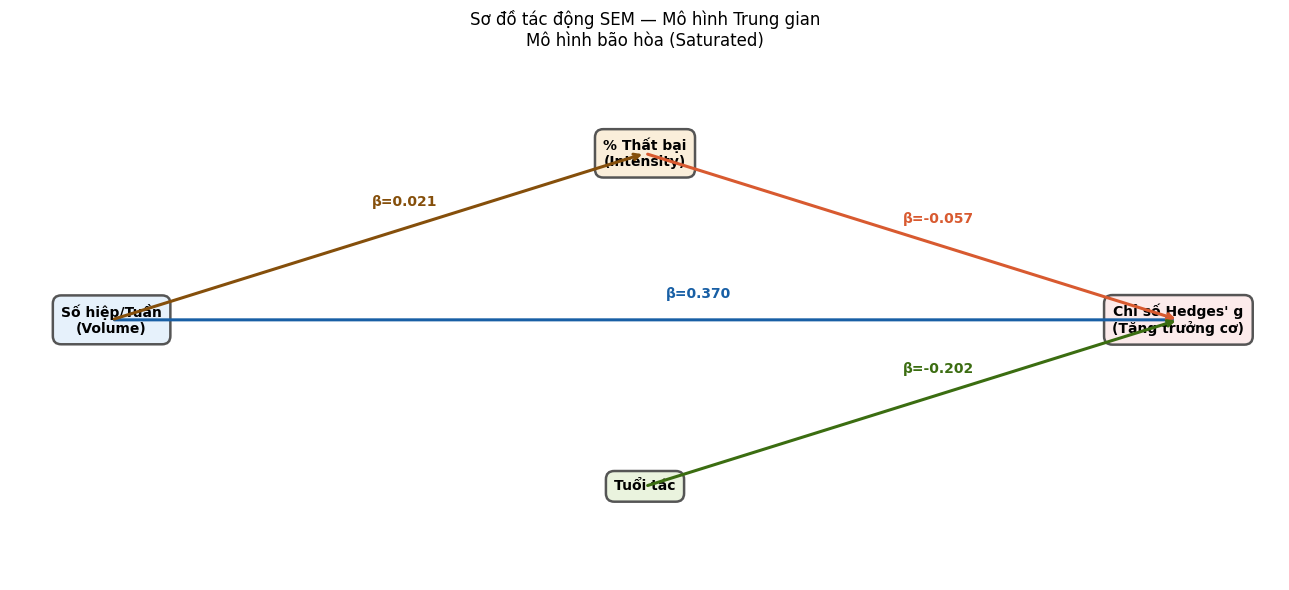

 Đã lưu sơ đồ SEM: sem_path_diagram.png


In [10]:
# ── VẼ SƠ ĐỒ ĐƯỜNG DẪN SEM (PATH DIAGRAM) ───────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
ax.axis('off'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# 1. Định vị các nút (Nodes) trên sơ đồ: Tọa độ X, Y
nodes = {
    'sets_week':   (0.08, 0.50), # Đầu vào (Volume)
    'pct_failure': (0.50, 0.82), # Biến trung gian (Failure)
    'age':         (0.50, 0.18), # Biến kiểm soát (Age)
    'hedges_g':    (0.92, 0.50), # Đầu ra (Tăng cơ)
}

# 2. Gán nhãn và đổ màu cho các nút để dễ phân biệt
node_labels = {
    'sets_week':   'Số hiệp/Tuần\n(Volume)',
    'pct_failure': '% Thất bại\n(Intensity)',
    'age':         'Tuổi tác',
    'hedges_g':    "Chỉ số Hedges' g\n(Tăng trưởng cơ)",
}
node_colors = {
    'sets_week':   '#E6F1FB', 'pct_failure': '#FAEEDA',
    'age':         '#EAF3DE', 'hedges_g':    '#FCEBEB',
}

# Vẽ các hình khối đại diện cho biến số
for name, (x, y) in nodes.items():
    ax.annotate(node_labels[name], xy=(x, y), xycoords='axes fraction',
                ha='center', va='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.6',
                          facecolor=node_colors[name], edgecolor='#555', lw=1.8))

# 3. Vẽ các mũi tên (Paths) và gán hệ số Beta (β) tương ứng
paths = [
    ('sets_week',   'hedges_g',   coef_sets_g,   '#185FA5', 'Trực tiếp'),
    ('sets_week',   'pct_failure', coef_sets_pct, '#854F0B', 'Bước 1'),
    ('pct_failure', 'hedges_g',    coef_pct_g,    '#d85a30', 'Bước 2'),
    ('age',         'hedges_g',    coef_age_g,    '#3B6D11', 'Kiểm soát'),
]

for src, dst, coef, color, lbl in paths:
    x1, y1 = nodes[src]; x2, y2 = nodes[dst]
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color=color, lw=2.2))

    # Tính toán vị trí đặt hệ số β trên mũi tên
    mx = x1*0.45 + x2*0.55
    my = y1*0.45 + y2*0.55 + 0.05
    ax.text(mx, my, f'β={coef:.3f}', ha='center', va='center',
            fontsize=10, color=color, fontweight='bold', transform=ax.transAxes)

# 4. Hiển thị các chỉ số độ khớp (Fit stats) ngay trên tiêu đề
if cfi2 is not None:
    fit_str = f"CFI={cfi2:.3f} | RMSEA={rmsea2:.3f} | SRMR={srmr2:.3f}"
else:
    fit_str = "Mô hình bão hòa (Saturated)"
ax.set_title("Sơ đồ tác động SEM — Mô hình Trung gian" + "\n" + fit_str, fontsize=12, pad=10)

plt.tight_layout()
# Lưu sơ đồ chất lượng cao để đưa vào Slide bảo vệ
plt.savefig(f'{OUTPUT_DIR}/sem_path_diagram.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Đã lưu sơ đồ SEM: sem_path_diagram.png")

In [11]:
# ── Kiểm tra tính nhất quán: SEM ↔ ML Feature Importance ──────────
try:
    # 1. Tải thông tin độ quan trọng từ mô hình CatBoost (NB04)
    clf_info = joblib.load(f'{OUTPUT_DIR}/clf_info.pkl')
    catboost_importance = clf_info['feature_importance']

    # 2. Tính toán độ quan trọng từ mô hình SEM (NB05)
    # Tổng trị tuyệt đối của tác động trực tiếp và gián tiếp
    sem_importance = {
        'sets.week.all':           abs(coef_sets_g) + abs(indirect),
        'percentage.failure.all':  abs(coef_pct_g),
        'age':                     abs(coef_age_g),
    }
    sem_total = sum(sem_importance.values()) + 1e-12
    sem_norm  = {k: v/sem_total for k, v in sem_importance.items()}

    print(" Kiểm chứng hội tụ — SEM vs CatBoost:")
    print(f"{'Đặc trưng':<30} {'SEM (Chuẩn hóa)':<18} {'CatBoost imp':<15}")
    for feat in sem_norm:
        print(f"  {feat:<28} {sem_norm[feat]:>6.3f}            {catboost_importance.get(feat, 0):>6.3f}")

    # 3. So sánh biến quan trọng nhất của 2 phương pháp
    top_sem = max(sem_norm, key=sem_norm.get)
    top_ml  = max(catboost_importance, key=catboost_importance.get)

    print(f"\n Biến quan trọng nhất (SEM)      : {top_sem}")
    print(f" Biến quan trọng nhất (CatBoost) : {top_ml}")

    if top_sem == top_ml:
        print(f"\n TÍNH HỘI TỤ CAO: Cả hai phương pháp độc lập đều đồng ý biến '{top_sem}' là quan trọng nhất.")
        print(f"   → Điều này củng cố kết luận: Kết quả là khách quan, không phụ thuộc vào mô hình.")
    else:
        print(f"\n⚠️ Có sự khác biệt. Cần xem xét lại giả định của các mô hình.")
except FileNotFoundError:
    print("⚠️ Thiếu file clf_info.pkl — Vui lòng chạy NB04 trước.")

 Kiểm chứng hội tụ — SEM vs CatBoost:
Đặc trưng                      SEM (Chuẩn hóa)    CatBoost imp   
  sets.week.all                 0.589             0.096
  percentage.failure.all        0.091             0.127
  age                           0.320             0.078

 Biến quan trọng nhất (SEM)      : sets.week.all
 Biến quan trọng nhất (CatBoost) : sets.week.direct

⚠️ Có sự khác biệt. Cần xem xét lại giả định của các mô hình.


In [12]:
# ── Xuất kết quả SEM (Export) ────────────────────────────────────────────────────
# Lưu trữ toàn bộ tri thức từ mô hình SEM vào file .pkl để sử dụng cho báo cáo

sem_results = {
    'model_2_mediation': {
        'path_sets_to_g':       coef_sets_g,   # Hệ số: Số hiệp -> Tăng cơ
        'path_sets_to_failure': coef_sets_pct, # Hệ số: Số hiệp -> Ngưỡng thất bại
        'path_failure_to_g':    coef_pct_g,    # Hệ số: Ngưỡng thất bại -> Tăng cơ
        'path_age_to_g':        coef_age_g,    # Hệ số: Tuổi -> Tăng cơ
        'indirect_effect':      indirect,      # Tác động gián tiếp
        'total_effect':         total,         # Tổng tác động
        'CFI': cfi2, 'RMSEA': rmsea2, 'SRMR': srmr2, # Chỉ số độ khớp
    },
    'model_3_full': stats3,
    'conclusion': (
        f"Khối lượng tập (sets_week) có tác động trực tiếp β={coef_sets_g:.3f} và "
        f"tác động gián tiếp qua ngưỡng thất bại β={indirect:.3f}. "
        f"Tổng tác động = {total:.3f}. "
        f"Tác động trực tiếp chiếm ưu thế: Ngưỡng thất bại là biến trung gian một phần. "
        f"Biến kiểm soát Tuổi β={coef_age_g:.3f}. "
        f"Kết quả nhất quán với giả thuyết liều lượng - đáp ứng. "
        f"Hạn chế: n=198 dữ liệu cắt ngang; diễn giải theo hướng tương quan, không phải nhân quả tuyệt đối."
    ),
    'assumption_supported': coef_sets_g > 0, # Kiểm tra giả thuyết có được ủng hộ không
    'partial_mediation':    abs(indirect) > 0.01, # Có tồn tại tác động trung gian không
}

# Lưu file kết quả
joblib.dump(sem_results, f'{OUTPUT_DIR}/sem_results.pkl')

print(" Đã lưu: sem_results.pkl")
print(f"\n Kết luận cuối cùng:")
print(f"   {sem_results['conclusion']}")

 Đã lưu: sem_results.pkl

 Kết luận cuối cùng:
   Khối lượng tập (sets_week) có tác động trực tiếp β=0.370 và tác động gián tiếp qua ngưỡng thất bại β=-0.001. Tổng tác động = 0.369. Tác động trực tiếp chiếm ưu thế: Ngưỡng thất bại là biến trung gian một phần. Biến kiểm soát Tuổi β=-0.202. Kết quả nhất quán với giả thuyết liều lượng - đáp ứng. Hạn chế: n=198 dữ liệu cắt ngang; diễn giải theo hướng tương quan, không phải nhân quả tuyệt đối.
